In [1]:
import numpy as np
import matplotlib.pyplot as plt

import healpy as hp

import pandas as pd

from astropy.io import fits

In [2]:
data = fits.open("2MASS-table3.dat.gz")
data.info()

Filename: 2MASS-table3.dat.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     121   ()      
  1  table3.dat    1 TableHDU       189   44599R x 29C   [A16, F9.5, F9.5, F9.5, F9.5, F6.3, F6.3, F6.3, F6.3, F6.3, F6.3, F5.3, F5.3, F5.3, F5.3, F5.3, F5.3, F5.3, F5.3, F5.3, F5.3, A4, A5, A2, I5, I3, A1, A19, A28]   


In [3]:
c = 1e5  # p[km/s]
data_2mass = data[1].data
ra, deg = data_2mass["RAdeg"], data_2mass["DEdeg"]
l, b = data_2mass["GLON"], data_2mass["GLAT"]
z, ez = data_2mass["cz"] / c, data_2mass["e_cz"] / c

galaxies = pd.DataFrame(np.array([ra, deg, l, b, z, ez]).T, columns=["ra", "dec", "l", "b", "z", "e_z"])
galaxies.head()


,ra,dec,l,b,z,e_z
0,10.68471,41.26875,121.17430,-21.57319,-0.00300,0.00004
1,11.88806,-25.28880,97.36301,-87.96452,0.00243,0.00002
2,148.88826,69.06526,142.09190,40.90022,-0.00034,0.00004
3,201.36565,-43.01871,309.51639,19.41761,0.00547,0.00005
4,196.36366,-49.46790,305.27151,13.34017,0.00563,0.00003


In [4]:
np.savez("./2mass-table", ra=galaxies["ra"], dec=galaxies["dec"], z=galaxies["z"])

In [5]:
# choose only good galaxies:
galaxies = galaxies[galaxies["z"] > 0.01]

In [6]:
# bins = [[0.01, 0.04], [0.04, 0.08], [0.08, 0.16], [0.16, 0.40]]   # binning
# bins = [[0.01, 0.04], [0.04, 0.08], [0.08, 0.13], [0.13, 0.17], [0.17, 0.27], [0.27, 0.5]]

bins = [[0.01, 0.04], [0.04, 0.07], [0.07, 0.10], [0.10, 0.14], [0.14, 0.18], [0.18, 0.40]]
bin_names = ["001-004", "004-007", "007-010", "010-014", "014-018", "018-040"]

gal_bins = []
for i in range(len(bins)):
    gal_bins.append(galaxies[(galaxies["z"] > bins[i][0]) * (galaxies["z"] <= bins[i][1])])

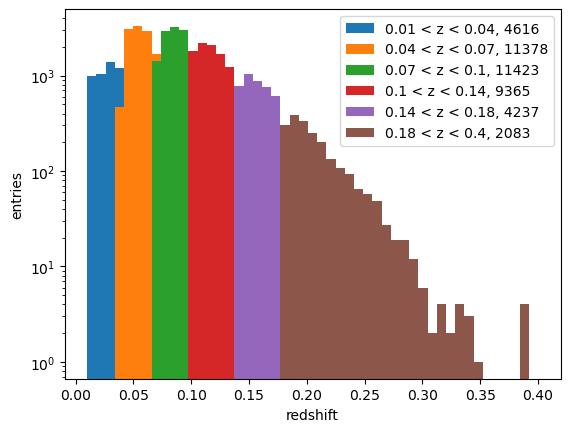

In [7]:
z_bins = np.linspace(0.01, 0.4, 50)
for i in range(len(bins)):
    plt.hist(gal_bins[i]["z"], bins=z_bins, label=f"{bins[i][0]} < z < {bins[i][1]}, {gal_bins[i]['z'].size}")

plt.xlabel('redshift')

plt.yscale('log')
plt.ylabel('entries')

plt.legend(loc=1)

plt.show()

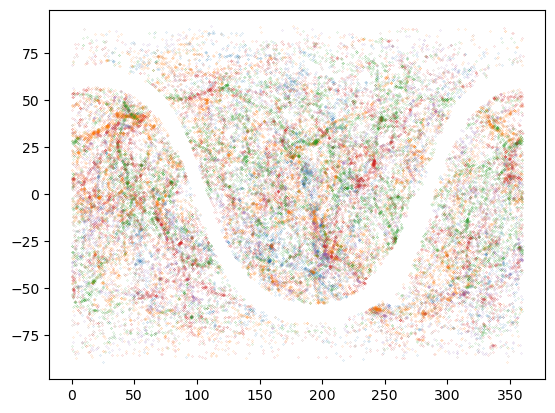

In [8]:
for i in range(len(bins)):
    plt.scatter(gal_bins[i]["ra"], gal_bins[i]["dec"], s=0.01)

## Healpix part

In [9]:
from astropy.coordinates import SkyCoord

nside = 128
npix = hp.nside2npix(nside)

mask = np.zeros(npix)

ra, dec = np.array(galaxies["ra"]), np.array(galaxies["dec"])
z = np.array(galaxies["z"])

theta_data = np.radians(90 - dec)
phi_data   = np.radians(ra)

# 1. all-sky mask
mask = np.ones(npix)

# 3. apply Galactic cut (pixel space!)
theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))

dec_pix, ra_pix = 90 - np.degrees(theta_pix), np.degrees(phi_pix)

coord = SkyCoord(ra=ra_pix, dec=dec_pix, unit='deg', frame='icrs').galactic
l_pix, b_pix = coord.l.deg, coord.b.deg

mask = np.abs(b_pix) > 10

### Mask (Chat-GPT recipie)

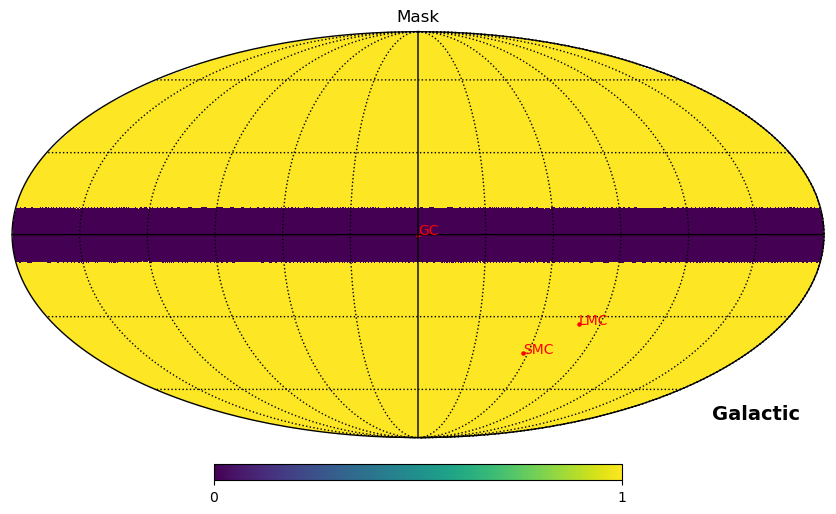

In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u

hp.mollview(mask, title="Mask", coord=['C', 'G'])

# LMC / SMC Galactic coordinates
l_gal = np.array([0, 280.5, 302.8])
b_gal = np.array([0, -32.9, -44.3])

objects = SkyCoord(l=l_gal, b=b_gal, unit='deg', frame='galactic')

# convert to healpy angles
theta_gal = np.radians(90 - b_gal)
phi_gal   = np.radians(l_gal)

# overplot
hp.projscatter(theta_gal, phi_gal, marker='o', color='red', s=5)

# optional labels
hp.projtext(theta_gal[0], phi_gal[0], "GC", color='red')
hp.projtext(theta_gal[1], phi_gal[1], "LMC", color='red')
hp.projtext(theta_gal[2], phi_gal[2], "SMC", color='red')

hp.graticule()
plt.show()

np.save("2mass_mask", mask)

### Generate random galaxies

In [11]:
from scipy.ndimage import gaussian_filter1d

hist, edges = np.histogram(np.log10(z), bins=50, density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

In [12]:
# GENERATE A RANDOM SOURCE FIELD 
N_rand = 50 * galaxies.z.size
print(galaxies.z.size)

cdf = np.cumsum(nz)
cdf /= cdf[-1]

def sample_z(N):
    u = np.random.rand(N)
    return np.interp(u, cdf, z_centers)

z_rand = 10**sample_z(N_rand)

43105


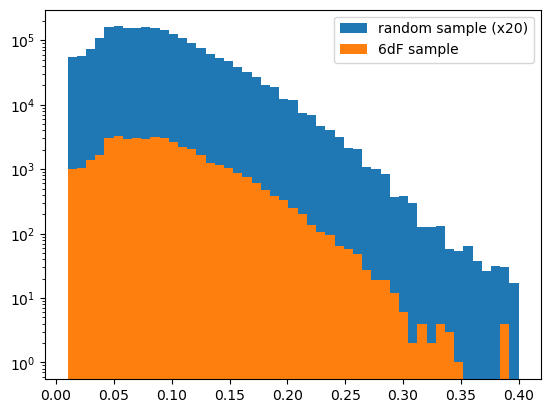

In [13]:
plt.hist(z_rand, bins=z_bins, label='random sample (x20)')
plt.hist(galaxies.z, bins=z_bins, label='6dF sample')
plt.legend()
plt.yscale('log')

### Combine with the mask

In [14]:
# distributing random sources in the sky

prob = mask.astype(float)
prob /= prob.sum()   # normalize

# draw pixel indices
npix = len(mask)
pix_rand = np.random.choice(np.arange(npix), size=N_rand, p=prob)

# convert to angles
theta_pix, phi_pix = hp.pix2ang(nside, pix_rand)

# pixel size
res = hp.nside2resol(nside)

# add sub-pixel jitter
theta_rand = theta_pix + np.random.uniform(-res/2, res/2, size=N_rand)
phi_rand   = phi_pix   + np.random.uniform(-res/2, res/2, size=N_rand)

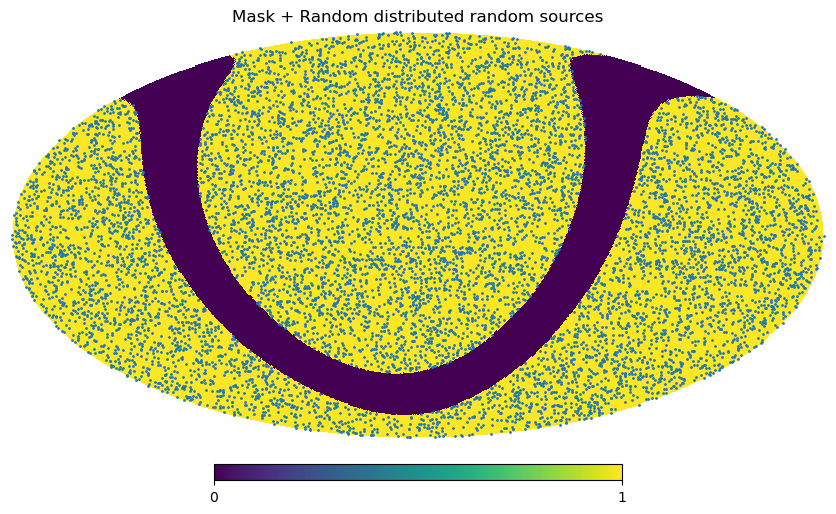

In [15]:
# sanity check of the randomly distributed sources
hp.mollview(mask, title="Mask + Random distributed random sources", rot=(180, 0, 0))
hp.projscatter(theta_rand[:10000], phi_rand[:10000], s=1)
plt.show()

### Plot overdensity

In [16]:
nside = 128
npix = hp.nside2npix(nside)
print(npix)


data_bins = []
rand_bins = []

for i in range(len(bins)):
    # data
    good_i = (z > bins[i][0]) * (z <= bins[i][1])
    pix_i = hp.ang2pix(nside, theta_data[good_i], phi_data[good_i])
    map_i = np.bincount(pix_i, minlength=npix)
    data_bins.append(map_i)
    np.save(f"2mass_{bin_names[i]}_data", map_i)
    
    # randoms
    good_r_i = (z_rand > bins[i][0]) * (z_rand <= bins[i][1])
    pix_r_i = hp.ang2pix(nside, theta_rand[good_r_i], phi_rand[good_r_i])
    map_r_i = np.bincount(pix_r_i, minlength=npix)
    rand_bins.append(map_r_i)
    np.save(f"2mass_{bin_names[i]}_rand", map_r_i)

196608


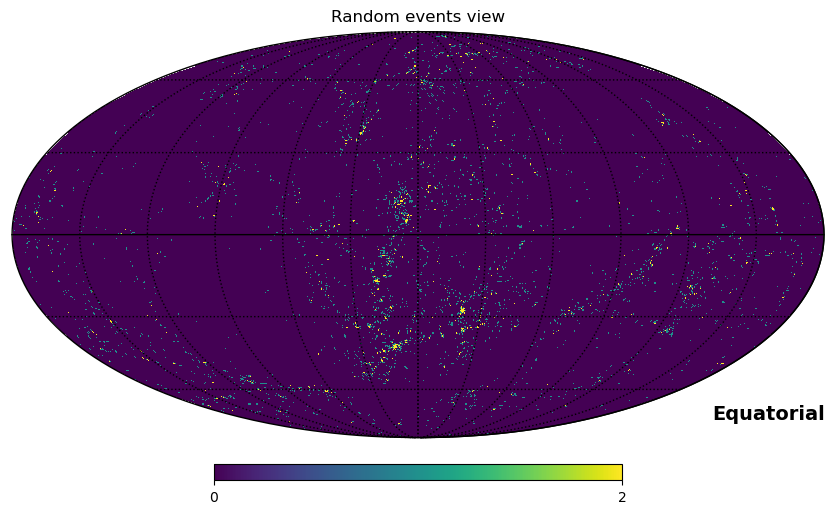

In [17]:
hp.mollview(data_bins[0], title="Random events view", rot=(180, 0, 0), coord='C', max=2)
hp.graticule()

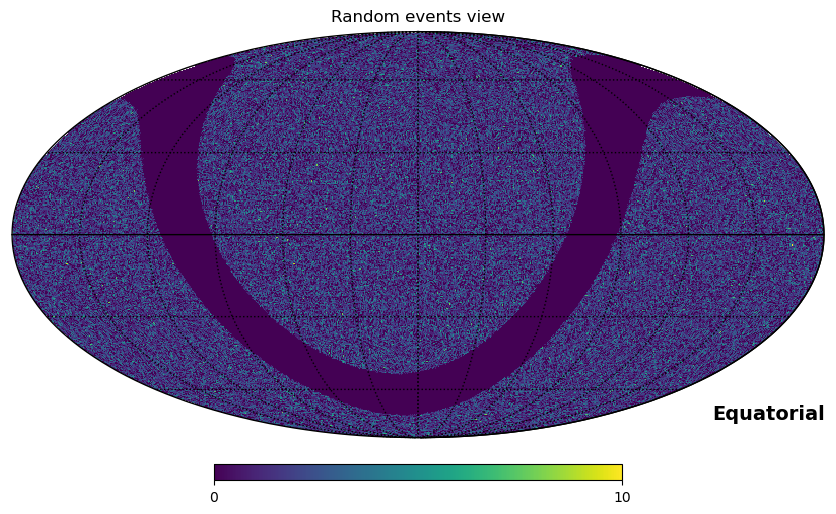

In [18]:
hp.mollview(rand_bins[0], title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

In [29]:
from astropy.coordinates import SkyCoord

MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg')
theta_MW, phi_MW = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

Eq_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg')
theta_Eq, phi_Eq = np.pi/2 - Eq_plane.dec.rad, Eq_plane.ra.rad

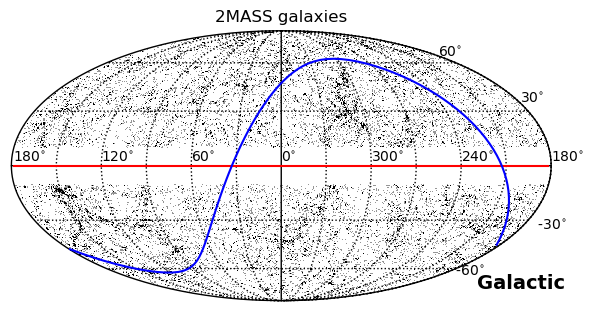

In [44]:
plt.figure(figsize=(7, 4))
ax = plt.subplot(111)
plt.sca(ax)
hp.mollview(np.sum(np.array(data_bins), axis=0) * mask, title="2MASS galaxies", coord=['C', 'G'],
            max=2, cmap='Grays', fig=1, xsize=900, cbar=False, hold=True)

hp.graticule()

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_Eq, phi_Eq, color='blue', coord='C')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

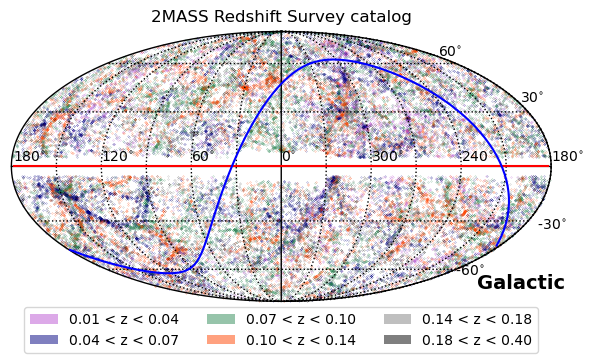

In [45]:
from matplotlib.patches import Patch

plt.figure(figsize=(7, 4))
ax = plt.subplot(111)
plt.sca(ax)
hp.mollview(np.zeros(npix), cmap='Greys', min=0, max=1, sub=None, hold=True,
            coord='G', cbar=False,
            title = "2MASS Redshift Survey catalog")

legend_elements = []
colors = ['mediumorchid', 'navy', 'seagreen', 'orangered', 'gray', 'black']
for i in range(len(bins)):
    legend_elements.append(Patch(facecolor=colors[i], alpha=0.5, label=f"{bins[i][0]:.2f} < z < {bins[i][1]:.2f}"))
    hp.projscatter(np.deg2rad(90 - gal_bins[i]["dec"]), np.deg2rad(gal_bins[i]["ra"]), s=0.02, color=colors[i],
                   coord='C')
    
plt.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.10), ncol=3)

hp.graticule()

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_Eq, phi_Eq, color='blue', coord='C')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

plt.savefig("../lss-2mass.png", bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

In [22]:
# OVERDENSITY FUNCTION

from astropy.cosmology import Planck18 as cosmo

delta_bins = []
delta_bins_s = []

for i in range(len(bins)):
    # normalization coefficient (data / sampling)
    alpha_i = np.sum(data_bins[i]) / (np.sum(rand_bins[i]))
    print(f"ALPHA: {1/alpha_i:.2f}")
    delta_i = np.zeros(npix, dtype=float)
    delta_s = np.zeros(npix, dtype=float)
    
    z_avg = (bins[i][0] + bins[i][1])/2
    sm_deg = np.min(((20 * u.Mpc / cosmo.kpc_comoving_per_arcmin(z_avg)).to_value(u.deg), 2.0))
    smoothing = np.deg2rad(sm_deg)
    print(f"{z_avg:.3f} <-> {sm_deg:.2f}")
    data_bins_s = np.clip(hp.smoothing(data_bins[i], sigma=smoothing), a_min=0.0, a_max=1e8)
    rand_bins_s = np.clip(hp.smoothing(rand_bins[i], sigma=smoothing), a_min=0.0, a_max=1e8)

    # delta_i[mask] = data_bins[i][mask] / (alpha_i * rand_bins[i][mask]) - 1
    # delta_bins.append(delta_i)`
    # delta_s = hp.smoothing(delta_i, sigma=smoothing)
    mask_i = mask * (rand_bins_s > 0)
    delta_s[mask_i] = data_bins_s[mask_i] / (alpha_i * rand_bins_s[mask_i]) - 1
    delta_bins_s.append(delta_s)

ALPHA: 56.52
0.025 <-> 2.00
ALPHA: 52.48
0.055 <-> 2.00
ALPHA: 50.23
0.085 <-> 2.00
ALPHA: 47.45
0.120 <-> 2.00
ALPHA: 44.59
0.160 <-> 1.68
ALPHA: 43.13
0.290 <-> 0.96


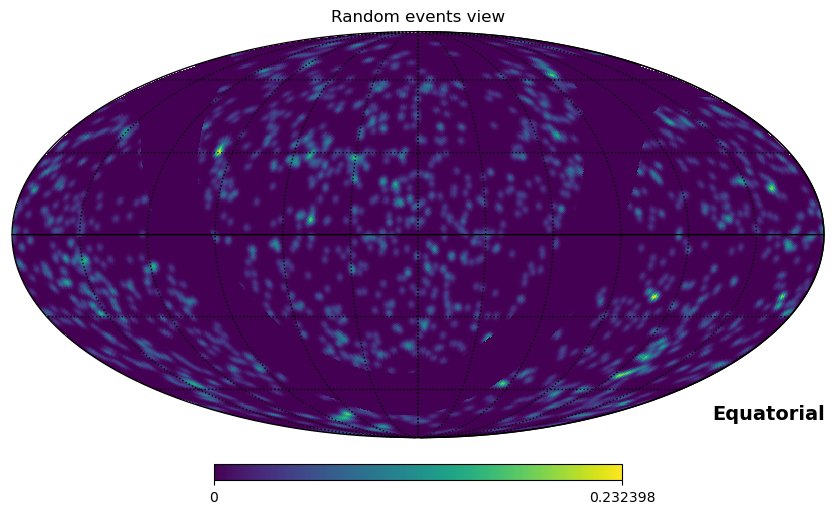

In [23]:
hp.mollview(data_bins_s * mask_i, title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

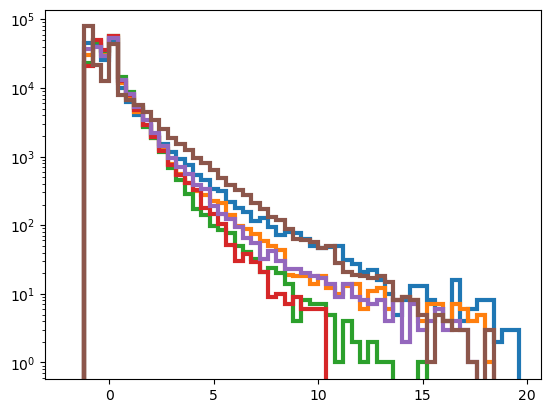

In [24]:
for i in range(len(bins)):
    plt.hist(delta_bins_s[i], bins = np.arange(-2.0, 20.0, 0.4), histtype='step', linewidth=3)
plt.yscale('log')
plt.show()

In [25]:
for i in range(len(bins)):
    print(np.nanmean(delta_bins_s[i][mask]))   # should be ~0
    print(np.nanstd(delta_bins_s[i][mask]))    # reasonable scatter

-0.050885822006069524
1.3668092549820985
-0.059978316242758144
1.0977983719948583
-0.04332306123882723
0.8995776101983856
-0.044229279589809496
0.9038121897877318
-0.03511328101448108
1.1058899393578985
-0.02026317417382555
1.5795019567321844


<Figure size 640x480 with 0 Axes>

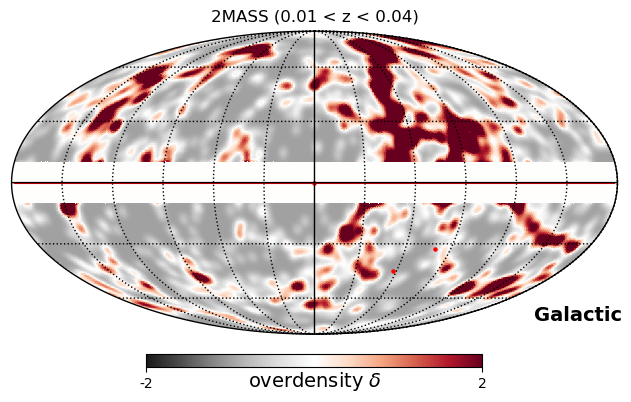

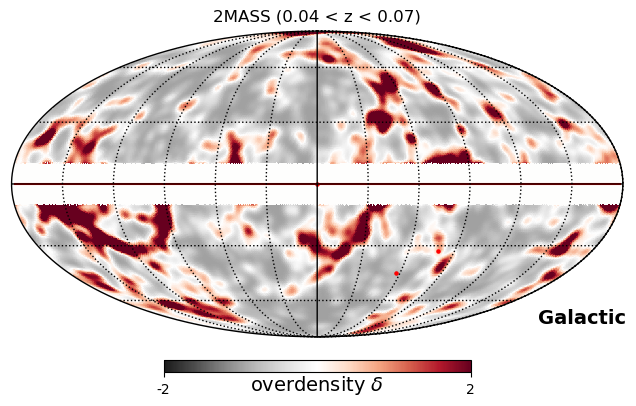

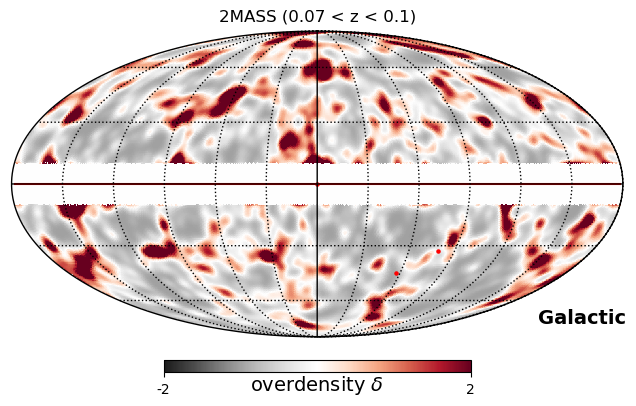

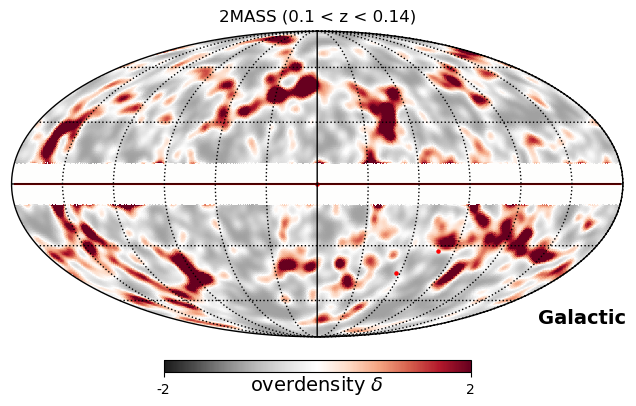

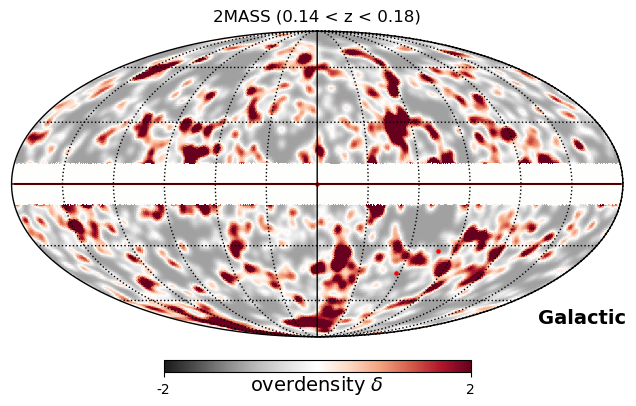

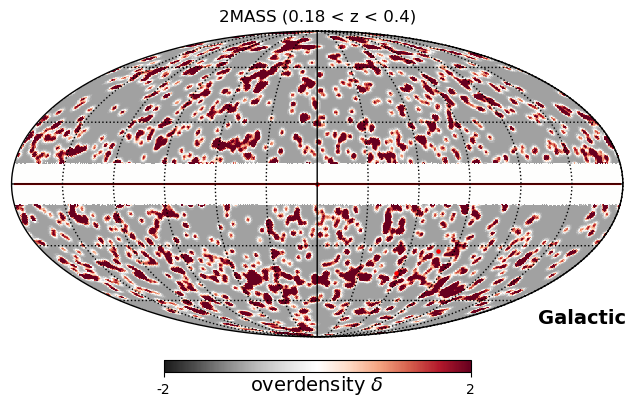

In [26]:
fig = plt.figure(figsize=(7, 4), num=1)

for i in range(len(bins)):
    plt.figure()
    hp.mollview(delta_bins_s[i],
                cmap='RdGy_r', min=-2, max=2, coord=['C', 'G'], title=f"2MASS ({bins[i][0]} < z < {bins[i][1]})",
                unit=r"overdensity $\delta$", fig=1, xsize=900)
    hp.projscatter(theta_gal, phi_gal, coord=['G', 'C'], marker='o', color='red', s=5)
    hp.projplot(theta_MW, phi_MW, coord='G', color='red')
    hp.graticule()
    plt.show()